# MNIST Digit Recognition: Dense Neural Network vs Convolutional Neural Network

This notebook is a **learning demo for students** comparing two approaches:

1. **Fully Connected Neural Network (Dense NN)** ~97–98% accuracy
2. **Convolutional Neural Network (CNN)** ~99% accuracy

We will:
- Download the MNIST dataset
- Train both models
- Compare accuracy
- Visualize neurons and CNN filters
- Draw your own digit and let the model predict it


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
print('TensorFlow:', tf.__version__)

TensorFlow: 2.19.0


## Download MNIST Dataset

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

print('Train:', x_train.shape)
print('Test:', x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train: (60000, 28, 28)
Test: (10000, 28, 28)


## Visualize Handwritten Digits

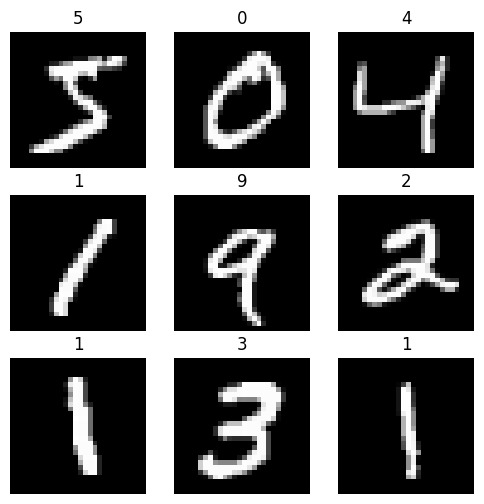

In [ ]:
plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')
plt.show()

## Model 1: Fully Connected Neural Network

This model **flattens the image into 784 pixels** and uses Dense layers.

In [ ]:
x_train_flat = x_train.reshape(-1,28*28)
x_test_flat = x_test.reshape(-1,28*28)

dense_model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

dense_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

dense_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### Train Dense Neural Network

In [ ]:
dense_history = dense_model.fit(
    x_train_flat,
    y_train,
    epochs=5,
    validation_data=(x_test_flat, y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8766 - loss: 0.4227 - val_accuracy: 0.9620 - val_loss: 0.1256
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9675 - loss: 0.1109 - val_accuracy: 0.9730 - val_loss: 0.0954
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9796 - loss: 0.0669 - val_accuracy: 0.9691 - val_loss: 0.1009
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9841 - loss: 0.0510 - val_accuracy: 0.9769 - val_loss: 0.0803
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9875 - loss: 0.0396 - val_accuracy: 0.9775 - val_loss: 0.0754


### Evaluate Dense Model

In [ ]:
dense_loss, dense_acc = dense_model.evaluate(x_test_flat, y_test)
print('Dense NN accuracy:', dense_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9738 - loss: 0.0897
Dense NN accuracy: 0.9775000214576721


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


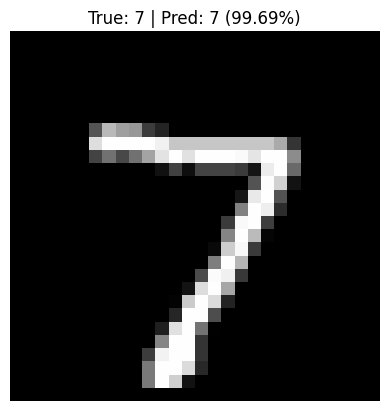

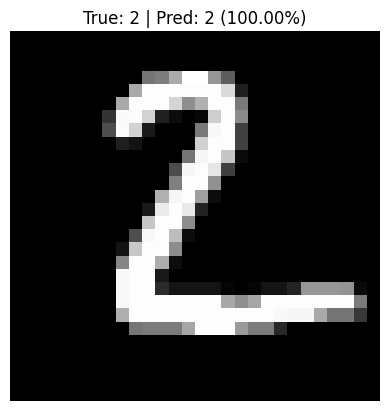

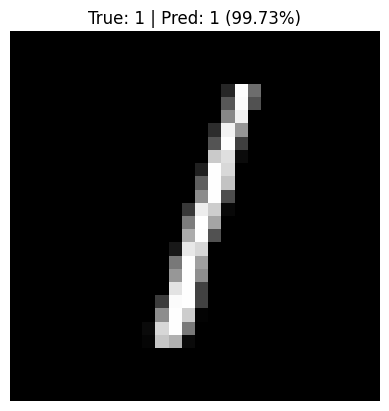

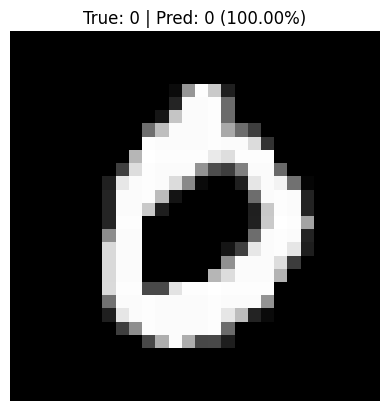

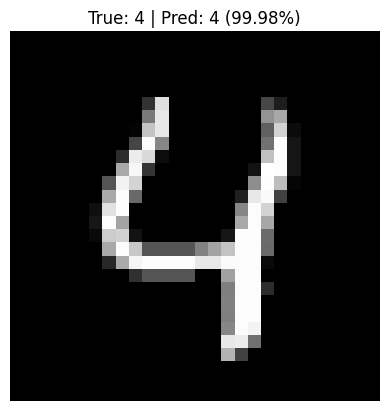

In [ ]:
predictions = dense_model.predict(x_test_flat)

for i in range(5):

    predicted_digit = np.argmax(predictions[i])
    confidence = np.max(predictions[i]) * 100

    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"True: {y_test[i]} | Pred: {predicted_digit} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()

## Visualizing Dense Layer Weights
Each neuron learns patterns across pixels.

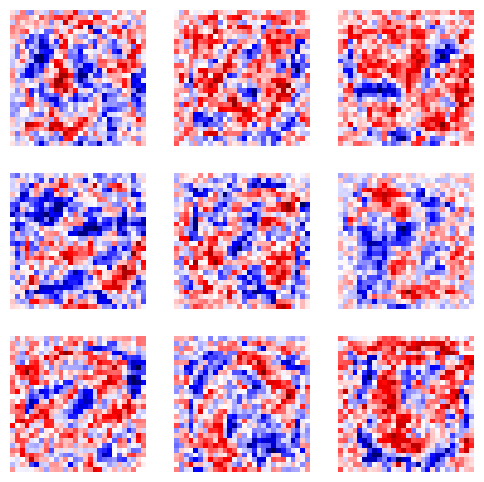

In [ ]:
weights = dense_model.layers[0].get_weights()[0]

plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(weights[:,i].reshape(28,28), cmap='seismic')
    plt.axis('off')
plt.show()

Feature
Dense Neural Network
Convolutional Neural Network
Input representation
Flattened image (784 vector)
2D image (28×28×1)
Spatial information
Lost
Preserved
Number of parameters
High
Lower (shared filters)
Feature learning
Global pixel relationships
Local edges & shapes
Training speed
Faster
Slightly slower
Typical MNIST accuracy
97–98%
98.5–99.3%
Best use cases
Tabular data
Images & vision


## Model 2: Convolutional Neural Network

CNNs detect **local features like edges and strokes**.

In [ ]:
x_train_cnn = x_train[..., np.newaxis]
x_test_cnn = x_test[..., np.newaxis]

cnn_model = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(10,activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

### Train CNN

In [ ]:
cnn_history = cnn_model.fit(
    x_train_cnn,
    y_train,
    epochs=5,
    validation_data=(x_test_cnn, y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.8886 - loss: 0.3462 - val_accuracy: 0.9829 - val_loss: 0.0494
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9856 - loss: 0.0478 - val_accuracy: 0.9888 - val_loss: 0.0344
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9905 - loss: 0.0306 - val_accuracy: 0.9890 - val_loss: 0.0339
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9926 - loss: 0.0233 - val_accuracy: 0.9914 - val_loss: 0.0317
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9942 - loss: 0.0184 - val_accuracy: 0.9919 - val_loss: 0.0270


### Evaluate CNN

In [ ]:
cnn_loss, cnn_acc = cnn_model.evaluate(x_test_cnn, y_test)
print('CNN accuracy:', cnn_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9888 - loss: 0.0352
CNN accuracy: 0.9919000267982483


## Visualize CNN Filters

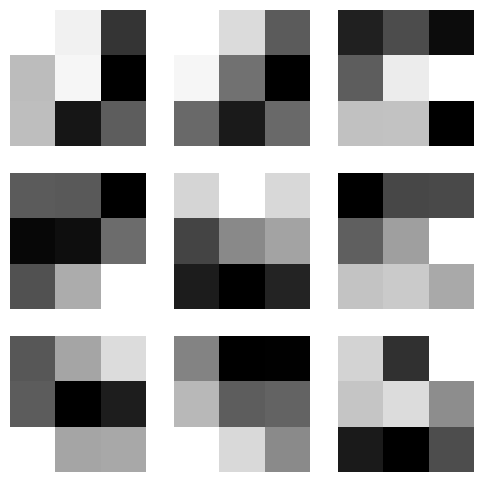

In [ ]:
filters, _ = cnn_model.layers[0].get_weights()

f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(filters[:,:,0,i], cmap='gray')
    plt.axis('off')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


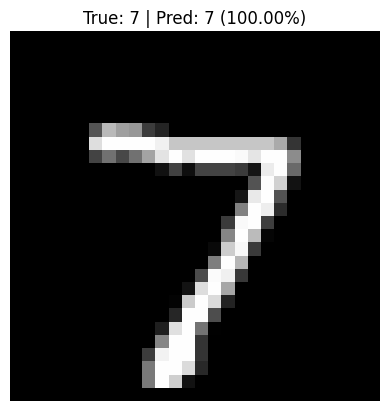

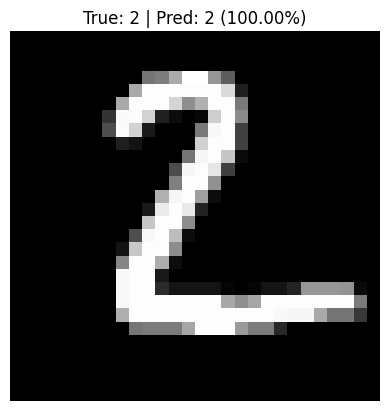

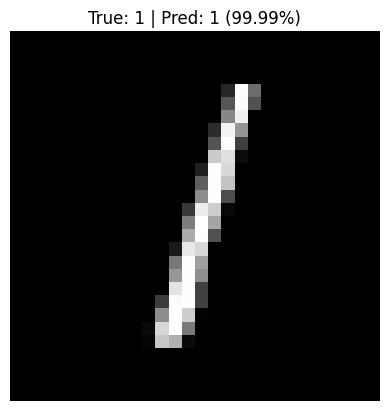

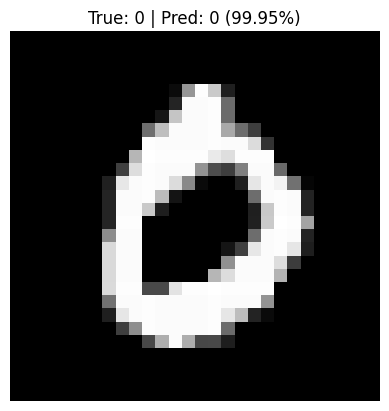

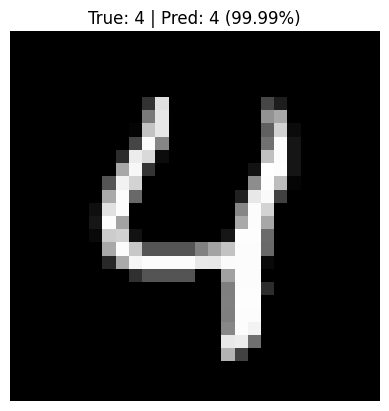

In [ ]:
predictions = cnn_model.predict(x_test_cnn)

for i in range(5):

    predicted_digit = np.argmax(predictions[i])
    confidence = np.max(predictions[i]) * 100

    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"True: {y_test[i]} | Pred: {predicted_digit} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()

## Compare the Two Models

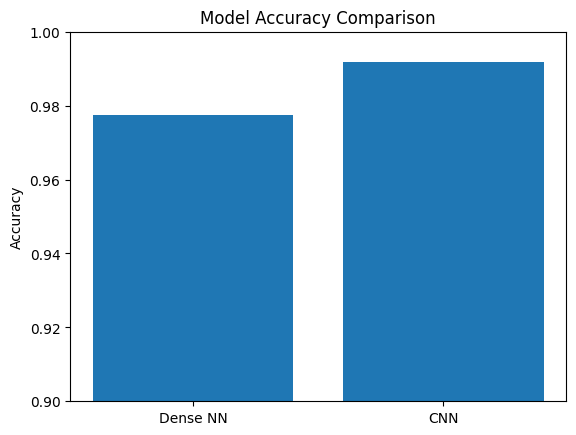

In [ ]:
models_names = ['Dense NN','CNN']
accuracies = [dense_acc, cnn_acc]

plt.bar(models_names, accuracies)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.9,1.0)
plt.show()

**Dense Neural Network vs Convolutional Neural Network**

| Feature | Dense Neural Network | Convolutional Neural Network (CNN) |
|---|---|---|
| Input representation | Flattened image vector (784 pixels) | 2D image structure (28 × 28 × 1) |
| Spatial information | Lost when image is flattened | Preserved through convolution layers |
| Parameter usage | Many parameters (fully connected) | Fewer parameters due to weight sharing |
| Feature learning | Learns global pixel relationships | Learns local patterns like edges and shapes |
| Translation invariance | Poor | Good (features detected anywhere in image) |
| Training speed | Faster for small models | Slightly slower but more powerful |
| Typical MNIST accuracy | ~97–98% | ~98.5–99.3% |
| Best use cases | Tabular data, simple datasets | Image recognition, computer vision |

## Draw Your Own Digit (Interactive)

Run the next 3 cells **in order**:
1. Define `predict(data)`
2. Register the callback
3. Show the canvas

Then draw a digit (0–9) and click **Predict**.


In [ ]:
from google.colab import output
import base64, io
import numpy as np
from PIL import Image

def predict(data_url):
    # data_url is like: 'data:image/png;base64,....'
    b64 = data_url.split(',')[1]
    img = Image.open(io.BytesIO(base64.b64decode(b64))).convert('L')
    img = img.resize((28, 28))
    arr = np.array(img)
    # Canvas uses white strokes on black background; convert to MNIST-like (white digit on black)
    arr = 255 - arr
    arr = arr.astype('float32') / 255.0
    x = arr.reshape(1, 28, 28, 1)

    probs = cnn_model.predict(x, verbose=0)[0]
    digit = int(np.argmax(probs))
    conf = float(np.max(probs))

    print(f"Predicted: {digit}  (confidence: {conf*100:.2f}%)")
    # Optional: show probability distribution
    import matplotlib.pyplot as plt
    plt.figure(figsize=(6,2.2))
    plt.bar(range(10), probs)
    plt.xticks(range(10))
    plt.ylim(0, 1)
    plt.xlabel('Digit')
    plt.ylabel('Probability')
    plt.show()


In [ ]:
from google.colab import output
import base64, io
import numpy as np
from PIL import Image, ImageOps

def preprocess_canvas_to_mnist(pil_img):
    # pil_img is grayscale (L), black bg with white strokes (we use that)
    arr = np.array(pil_img)

    # If it's mostly black, likely nothing was drawn
    if arr.max() < 30:
        return None

    # Find bounding box of the white strokes
    ys, xs = np.where(arr > 30)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()

    # Crop to content
    crop = pil_img.crop((x0, y0, x1 + 1, y1 + 1))

    # Add padding (so digit isn't touching borders)
    pad = 20
    crop = ImageOps.expand(crop, border=pad, fill=0)

    # Make square by padding the shorter side
    w, h = crop.size
    if w > h:
        crop = ImageOps.expand(crop, border=(0, (w-h)//2, 0, (w-h) - (w-h)//2), fill=0)
    elif h > w:
        crop = ImageOps.expand(crop, border=((h-w)//2, 0, (h-w) - (h-w)//2, 0), fill=0)

    # Resize to MNIST 28x28
    crop = crop.resize((28, 28), Image.Resampling.LANCZOS)

    # Normalize
    x = np.array(crop).astype("float32") / 255.0
    x = x.reshape(1, 28, 28, 1)
    return x

def predict(data_url):
    b64 = data_url.split(",")[1]
    img = Image.open(io.BytesIO(base64.b64decode(b64))).convert("L")

    x = preprocess_canvas_to_mnist(img)
    if x is None:
        print("Nothing detected — draw a digit first 🙂")
        return

    probs = cnn_model.predict(x, verbose=0)[0]
    digit = int(np.argmax(probs))
    conf = float(np.max(probs))

    print(f"Predicted: {digit}  (confidence: {conf*100:.2f}%)")

    import matplotlib.pyplot as plt
    plt.figure(figsize=(6,2.2))
    plt.bar(range(10), probs)
    plt.xticks(range(10))
    plt.ylim(0, 1)
    plt.xlabel("Digit")
    plt.ylabel("Probability")
    plt.show()

output.register_callback("notebook.predict", predict)
print("Callback registered: notebook.predict")

Callback registered: notebook.predict


In [ ]:
# Register the JS -> Python callback
output.register_callback('notebook.predict', predict)
print('Callback registered: notebook.predict')


Callback registered: notebook.predict


<IPython.core.display.Javascript object>

Predicted: 4  (confidence: 100.00%)


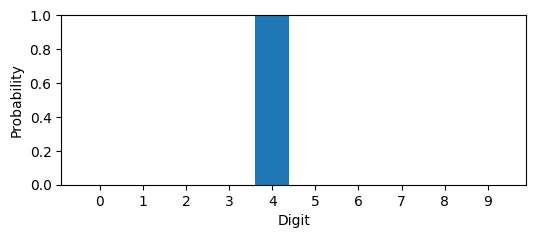

Predicted: 6  (confidence: 50.54%)


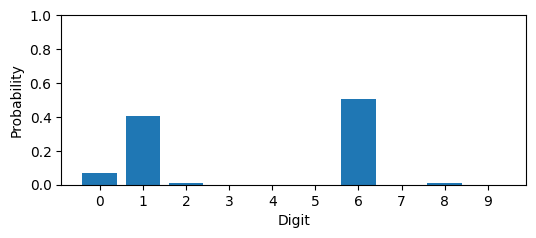

Predicted: 0  (confidence: 99.71%)


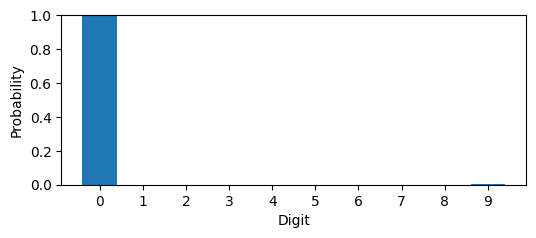

Predicted: 0  (confidence: 100.00%)


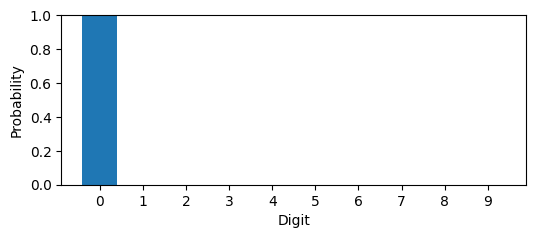

Predicted: 6  (confidence: 99.01%)


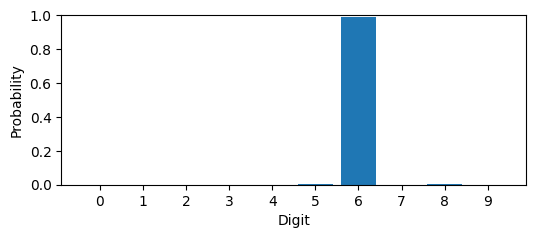

In [ ]:
from IPython.display import display, HTML, Javascript

# Render HTML first (so elements exist), then wire up JS handlers.
display(HTML('''
<div id="mnist-draw-root" style="max-width: 320px;">
PLEASE DRAW A NUMBER BELOW:
  <canvas id="mnist-canvas" width="280" height="280" style="border:1px solid #000;"></canvas>
  <div style="margin-top:8px; display:flex; gap:8px;">
    <button id="mnist-clear">Clear</button>
    <button id="mnist-predict">Predict</button>
  </div>
  <div style="margin-top:8px; font-family: monospace;" id="mnist-status"></div>
</div>
'''))

display(Javascript('''
(function() {
  const canvas = document.getElementById('mnist-canvas');
  const clearBtn = document.getElementById('mnist-clear');
  const predBtn = document.getElementById('mnist-predict');
  const status = document.getElementById('mnist-status');
  if (!canvas || !clearBtn || !predBtn) {
    console.log('Canvas elements not found.');
    return;
  }

  const ctx = canvas.getContext('2d');
  // Black background
  ctx.fillStyle = 'black';
  ctx.fillRect(0, 0, canvas.width, canvas.height);
  // White brush
  ctx.strokeStyle = 'white';
  ctx.lineWidth = 20;
  ctx.lineCap = 'round';

  let drawing = false;

  function getPos(e) {
    const r = canvas.getBoundingClientRect();
    return { x: e.clientX - r.left, y: e.clientY - r.top };
  }

  canvas.addEventListener('pointerdown', (e) => {
    drawing = true;
    const p = getPos(e);
    ctx.beginPath();
    ctx.moveTo(p.x, p.y);
  });

  canvas.addEventListener('pointerup', () => {
    drawing = false;
    ctx.beginPath();
  });

  canvas.addEventListener('pointermove', (e) => {
    if (!drawing) return;
    const p = getPos(e);
    ctx.lineTo(p.x, p.y);
    ctx.stroke();
    ctx.beginPath();
    ctx.moveTo(p.x, p.y);
  });

  clearBtn.addEventListener('click', () => {
    ctx.fillStyle = 'black';
    ctx.fillRect(0, 0, canvas.width, canvas.height);
    status.textContent = '';
  });

  predBtn.addEventListener('click', async () => {
    status.textContent = 'Sending to model...';
    const data = canvas.toDataURL('image/png');
    try {
      // This calls the Python callback we registered: notebook.predict
      await google.colab.kernel.invokeFunction('notebook.predict', [data], {});
      status.textContent = 'Done (see output below).';
    } catch (err) {
      console.error(err);
      status.textContent = 'Error calling Python callback. Make sure you ran the register cell.';
    }
  });
})();
'''))
